In [1]:
import os
import cv2
import numpy as np
import random
from pathlib import Path
from PIL import Image
import shutil

In [6]:
bmp_path = Path(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single\HSIL\2b_1.bmp')
img = Image.open(bmp_path).convert("RGB")
new_name = bmp_path.with_suffix('.jpg')
img.save(new_name)
img = cv2.imread(str(bmp_path), cv2.IMREAD_UNCHANGED)

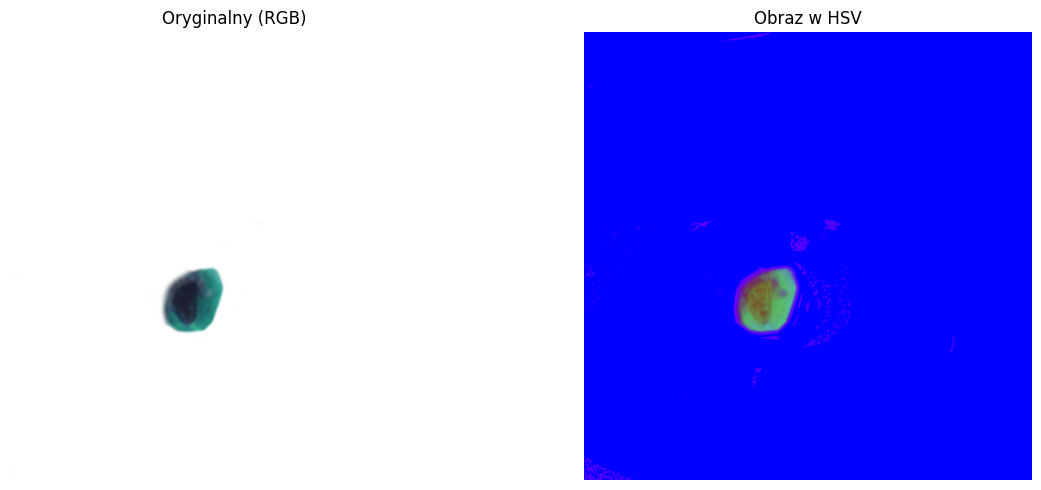

In [8]:
import matplotlib.pyplot as plt
img_bgr = cv2.imread(bmp_path)  
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  

img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Oryginalny (RGB)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_hsv)
plt.title('Obraz w HSV')
plt.axis('off')

plt.tight_layout()
plt.show()


In [3]:
def segment_and_crop_cell(img):
    img_rgb = img[:, :, :3] if img.shape[2] == 4 else img
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 10, 10])
    upper = np.array([180, 255, 240])
    mask = cv2.inRange(hsv, lower, upper)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    coords = cv2.findNonZero(mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        margin = 5
        x = max(x - margin, 0)
        y = max(y - margin, 0)
        w = min(w + 2 * margin, img.shape[1] - x)
        h = min(h + 2 * margin, img.shape[0] - y)
        cropped = img[y:y+h, x:x+w]
        return cropped, (w, h)
    return img, (img.shape[1], img.shape[0])
import matplotlib.pyplot as plt

def show_segmented_cell(img):
    cropped, (w, h) = segment_and_crop_cell(img.copy())
    img_rgb = img[:, :, :3] if img.shape[2] == 4 else img
    mask = np.zeros(img.shape[:2], dtype=np.uint8)

    # Ponownie HSV i maska
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 10, 10])
    upper = np.array([180, 255, 240])
    mask = cv2.inRange(hsv, lower, upper)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))

    # BBOX z maski
    coords = cv2.findNonZero(mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img_bbox = img.copy()
        cv2.rectangle(img_bbox, (x, y), (x+w, y+h), (0, 0, 255), 2)
        plt.imshow(cv2.cvtColor(img_bbox, cv2.COLOR_BGR2RGB))
        plt.title("Segmentacja + BBox")
        plt.axis("off")
        plt.show()
    else:
        print("Nie znaleziono komórki.")


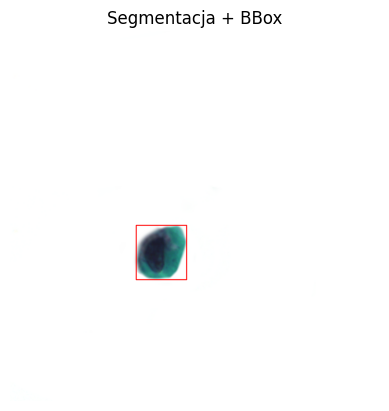

In [4]:
show_segmented_cell(img)